# Predictive Modeling: Artificial Neural Network (ANN)

This notebook builds an Artificial Neural Network (ANN) to predict customer churn using the preprocessed datasets provided by the data engineering team.

The dataset has already been:
- cleaned  
- encoded  
- scaled  
- split into training and testing sets  

This notebook focuses on:
- model architecture  
- model training  
- model evaluation  
- visualisation  
- interpretation  

This work supports the Predictive Modeling role in the ACS WIL internship project.


## Importing Required Libraries

We import the core libraries used for:
- data handling  
- model building  
- evaluation  
- visualisation  

TensorFlow/Keras is used for the ANN.  
Scikit‑learn provides evaluation metrics and ROC curve utilities.


In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Deep learning (Keras/TensorFlow)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns


## Loading the Preprocessed Datasets

The data engineering team has already prepared the following files:

- **02_train_model_ready.csv** — training dataset  
- **03_test_model_ready.csv** — testing dataset  

These files contain fully processed features:
- encoded  
- scaled  
- cleaned  
- ready for modeling  

We simply load them into memory.


In [13]:
# Load the preprocessed datasets
train_df = pd.read_csv("02_train_model_ready.csv")
test_df = pd.read_csv("03_test_model_ready.csv")

train_df.head()


,tenure,MonthlyCharges,SeniorCitizen,gender_Male,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,Contract_One year,Contract_Two year,Churn
0,-1.274297,-1.320425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.351087,-1.320425,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0
2,1.407587,-0.457524,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0
3,1.448221,0.836827,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1
4,-0.380336,0.405377,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0


## Splitting Features and Target

The target variable is **Churn** (0 = No, 1 = Yes).

We separate:
- **X** → all input features  
- **y** → churn label  

This prepares the data for ANN training and evaluation.


In [3]:
# Features and target split
X_train = train_df.drop("Churn", axis=1)
y_train = train_df["Churn"]

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

# Confirm shape
X_train.shape, X_test.shape


((5635, 10), (1408, 10))

## Building the ANN Model

We construct a simple feed‑forward neural network with:

- **Input layer** — matches the number of features  
- **Hidden Layer 1** — 64 neurons, ReLU activation  
- **Dropout** — reduces overfitting  
- **Hidden Layer 2** — 32 neurons, ReLU activation  
- **Dropout** — additional regularisation  
- **Output Layer** — 1 neuron, sigmoid activation (predicts churn probability)

The model is compiled using:
- **Adam optimizer**  
- **Binary crossentropy loss**  
- **Accuracy metric**


In [14]:
# Build a simple ANN model
model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),  # Input + first hidden layer
    Dropout(0.3),                                              # Helps prevent overfitting
    Dense(32, activation='relu'),                              # Second hidden layer
    Dropout(0.2),
    Dense(1, activation='sigmoid')                             # Output layer for binary classification
])

# Compile the model
model.compile(
    optimizer='adam',                 # Adaptive learning rate
    loss='binary_crossentropy',       # Standard for binary classification
    metrics=['accuracy']              # Track accuracy during training
)

# Display model architecture
model.summary()


E:\Users\sujin\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

## Training the ANN Model

We train the model using:
- 50 epochs  
- batch size of 32  
- 20% validation split  

The training process helps us monitor:
- loss reduction  
- accuracy improvement  
- validation performance  


In [15]:
# Train the ANN model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,   # 20% of training data used for validation
    epochs=50,              # Number of passes through the dataset
    batch_size=32,          # Samples per gradient update
    verbose=1               # Show training progress
)


Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7141 - loss: 0.5469 - val_accuracy: 0.7817 - val_loss: 0.4584
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7740 - loss: 0.4739 - val_accuracy: 0.7711 - val_loss: 0.4492
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7799 - loss: 0.4619 - val_accuracy: 0.7720 - val_loss: 0.4471
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7879 - loss: 0.4583 - val_accuracy: 0.7720 - val_loss: 0.4462
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7873 - loss: 0.4564 - val_accuracy: 0.7622 - val_loss: 0.4459
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7848 - loss: 0.4574 - val_accuracy: 0.7720 - val_loss: 0.4454
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7917 - loss: 0.4575 - val_accuracy: 0.7693 - val_loss: 0.4452
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7886 - loss: 0.4537 - val_accuracy: 0.

## Visualising Training Performance

We plot:
- **Training vs Validation Loss**
- **Training vs Validation Accuracy**

These curves help diagnose:
- overfitting  
- underfitting  
- model stability  


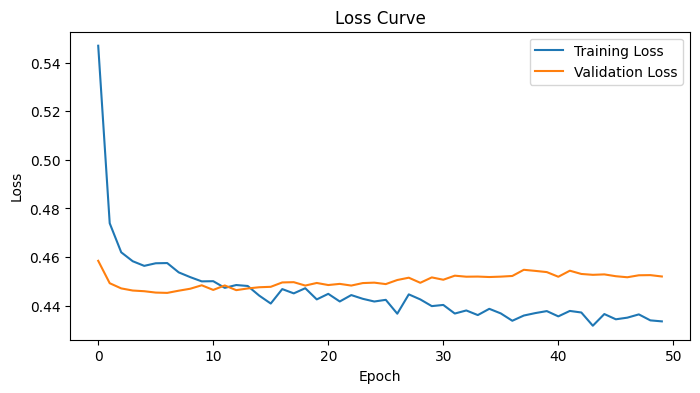

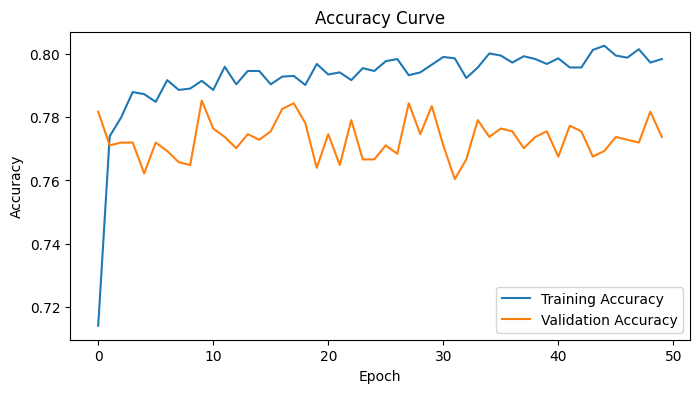

In [16]:
# Plot training & validation loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot training & validation accuracy
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


## Generating Predictions

The ANN outputs churn probabilities between 0 and 1.

We convert these probabilities into binary predictions:
- '>' 0.5 → churn  
- ≤ 0.5 → no churn  

These predictions are used for evaluation.


In [8]:
# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to 0/1
y_pred = (y_pred_prob > 0.5).astype(int)


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


## Model Evaluation Metrics

We compute the following metrics:

- **Accuracy** — overall correctness  
- **Precision** — correctness of churn predictions  
- **Recall** — ability to detect churners  
- **F1 Score** — balance between precision and recall  
- **AUC** — ability to separate churn vs non‑churn  

These metrics form the core of the Stage 3 report.


In [17]:
# Calculate evaluation metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
print("AUC:", auc)


Accuracy: 0.8025568181818182
Precision: 0.6819923371647509
Recall: 0.4772117962466488
F1 Score: 0.5615141955835962
AUC: 0.831091424796985


## Confusion Matrix

The confusion matrix shows:
- True Negatives  
- False Positives  
- False Negatives  
- True Positives  

This helps evaluate how well the model identifies churners vs non‑churners.


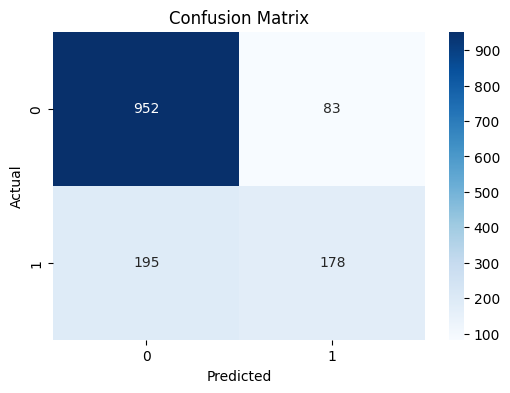

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## ROC Curve and AUC

The ROC curve visualises the trade‑off between:
- True Positive Rate  
- False Positive Rate  

The **AUC score** summarises the model’s ability to distinguish churn vs non‑churn customers.


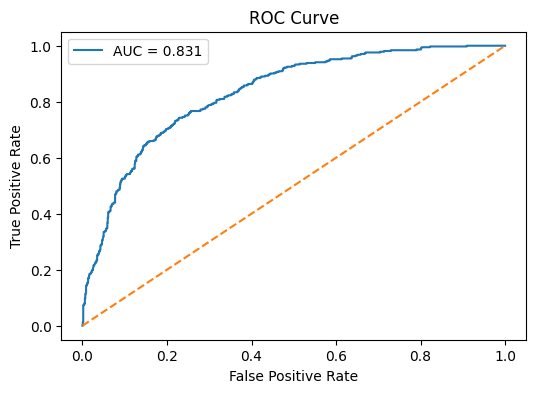

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# Conclusion

This ANN model provides a predictive framework for identifying customers at risk of churn.

The evaluation metrics (accuracy, precision, recall, F1, AUC) indicate how well the model performs and guide future improvements such as:
- hyperparameter tuning  
- deeper architectures  
- feature importance analysis  
- threshold optimisation  

These results will be included in the Stage 3 Final Report and support retention strategy recommendations.
